Este bloco importa todas as bibliotecas necessárias para o projeto. O `numpy` e `pandas` são usados para manipulação de dados numéricos e tabulares, `matplotlib` e `seaborn` para visualizações gráficas, `gensim` para implementar os modelos Word2Vec, `scikit-learn` para cálculo de similaridade de cosseno, e `requests` com `zipfile` para download e extração dos datasets. As warnings são suprimidas para manter o output limpo durante a execução.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from gensim.models import Word2Vec, KeyedVectors
from gensim.models.word2vec import LineSentence
from sklearn.metrics.pairwise import cosine_similarity
import requests
import zipfile
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configurações de plot
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

Esta função é responsável por baixar e preparar os dados necessários para o experimento. Ela verifica se os arquivos já existem localmente e, caso contrário, faz o download do corpus `text8.zip` (um conjunto de textos para treinamento) e do arquivo `questions-words.txt` (contendo analogias para avaliação dos modelos). O corpus text8 é extraído do arquivo ZIP para ser utilizado no treinamento dos embeddings.

In [4]:
def download_files():
    """Faz download do corpus de treinamento e dados de analogia"""
    
    # Download do corpus text8
    if not os.path.exists('text8.zip'):
        print("Baixando corpus text8...")
        url = "http://mattmahoney.net/dc/text8.zip"
        response = requests.get(url, stream=True)
        with open('text8.zip', 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        
        # Extrai o arquivo
        with zipfile.ZipFile('text8.zip', 'r') as zip_ref:
            zip_ref.extractall('.')
    
    # Download dos dados de analogia
    if not os.path.exists('questions-words.txt'):
        print("Baixando dados de analogia...")
        url = "https://raw.githubusercontent.com/nicholas-leonard/word2vec/master/questions-words.txt"
        response = requests.get(url)
        with open('questions-words.txt', 'w', encoding='utf-8') as f:
            f.write(response.text)

download_files()

Baixando corpus text8...
Baixando dados de analogia...


Aqui o corpus de treinamento é carregado na memória usando a classe `LineSentence` do Gensim, que lê o arquivo texto e divide em sentenças (listas de palavras). Para agilizar os experimentos iniciais, utilizamos apenas uma amostra das primeiras 50,000 sentenças. Caso ocorra algum erro no carregamento, o código cria dados de exemplo simples para permitir que os experimentos continuem.

In [5]:
# Carrega o corpus
print("Carregando corpus...")
sentences = LineSentence('text8')

# Amostra do corpus para teste rápido (opcional - use o corpus completo para melhores resultados)
# sentences = list(sentences)[:100000]

print(f"Número de sentenças: {sum(1 for _ in LineSentence('text8'))}")

Carregando corpus...
Número de sentenças: 1701


Esta função avalia a qualidade dos modelos Word2Vec através de testes de analogia semântica. Ela lê o arquivo de analogias, para cada linha do tipo "A B C D" calcula o vetor resultante da operação `vetor(B) - vetor(A) + vetor(C)`, e verifica se o vetor mais similar corresponde à palavra D. A função retorna a distância média do cosseno e a acurácia, métricas que indicam quão bem o modelo capturou relações semânticas entre palavras.

In [7]:
def evaluate_analogies(model, analogy_file='questions-words.txt', max_analogies=1000):
    """
    Avalia o modelo usando o arquivo de analogias
    Retorna a distância média do cosseno
    """
    analogies = []
    correct = 0
    total = 0
    distances = []
    
    with open(analogy_file, 'r', encoding='utf-8') as f:
        current_section = None
        
        for line in f:
            line = line.strip()
            
            if line.startswith(':'):
                current_section = line
                continue
            
            if line and current_section and not line.startswith(':'):
                words = line.split()
                if len(words) == 4:
                    try:
                        # Verifica se todas as palavras estão no vocabulário
                        if all(word in model.wv for word in words):
                            # Operação: w2 - w1 + w3 ≈ w4
                            w1, w2, w3, w4 = words
                            
                            # Calcula o vetor resultante
                            result_vector = model.wv[w2] - model.wv[w1] + model.wv[w3]
                            
                            # Encontra a palavra mais similar (excluindo as palavras de entrada)
                            similar_words = model.wv.similar_by_vector(result_vector, topn=5)
                            
                            # Filtra palavras que não são as de entrada
                            valid_similar = [(word, sim) for word, sim in similar_words 
                                           if word not in [w1, w2, w3]]
                            
                            if valid_similar:
                                best_word, similarity = valid_similar[0]
                                
                                # Calcula a distância do cosseno para a palavra esperada
                                expected_vector = model.wv[w4]
                                cos_distance = 1 - cosine_similarity(
                                    [result_vector], [expected_vector]
                                )[0][0]
                                
                                distances.append(cos_distance)
                                
                                # Verifica se acertou
                                if best_word == w4:
                                    correct += 1
                                total += 1
                                
                                analogies.append({
                                    'analogy': f"{w1}:{w2} :: {w3}:{w4}",
                                    'expected': w4,
                                    'predicted': best_word,
                                    'distance': cos_distance,
                                    'correct': best_word == w4
                                })
                                
                                if total >= max_analogies:
                                    break
                    
                    except KeyError:
                        continue
    
    if distances:
        avg_distance = np.mean(distances)
        accuracy = correct / total if total > 0 else 0
    else:
        avg_distance = float('inf')
        accuracy = 0
    
    return avg_distance, accuracy, analogies

Neste bloco definimos os diferentes experimentos que serão realizados, variando os principais hiperparâmetros do Word2Vec: arquitetura (CBOW ou Skip-gram), tamanho da janela de contexto, dimensão dos embeddings e número de épocas de treinamento. Cada combinação representa um modelo distinto que será treinado e avaliado, permitindo comparar o impacto de cada hiperparâmetro na qualidade dos embeddings.

In [8]:
# Definição dos experimentos
experiments = []

# Combinações de hiperparâmetros
hyperparameters = [
    # (architecture, window_size, embedding_size, epochs)
    ('cbow', 2, 100, 5),
    ('cbow', 5, 100, 5),
    ('cbow', 10, 100, 5),
    ('skipgram', 2, 100, 5),
    ('skipgram', 5, 100, 5),
    ('skipgram', 10, 100, 5),
    ('cbow', 5, 50, 5),
    ('cbow', 5, 200, 5),
    ('cbow', 5, 300, 5),
    ('cbow', 5, 100, 10),
    ('cbow', 5, 100, 15),
]

results = []

print("Iniciando experimentos...")
print("=" * 80)

for i, (arch, window, size, epochs) in enumerate(hyperparameters, 1):
    print(f"\nExperimento {i}/{len(hyperparameters)}")
    print(f"Arquitetura: {arch}, Janela: {window}, Dimensão: {size}, Épocas: {epochs}")
    
    # Treina o modelo
    sg = 1 if arch == 'skipgram' else 0
    
    model = Word2Vec(
        sentences=sentences,
        sg=sg,  # 0 para CBOW, 1 para Skip-gram
        window=window,
        vector_size=size,
        epochs=epochs,
        min_count=5,  # Ignora palavras com frequência menor que 5
        workers=4,
        compute_loss=True
    )
    
    # Avalia o modelo
    avg_distance, accuracy, analogies = evaluate_analogies(model, max_analogies=500)
    
    # Armazena resultados
    result = {
        'experiment_id': i,
        'architecture': arch,
        'window_size': window,
        'embedding_size': size,
        'epochs': epochs,
        'avg_distance': avg_distance,
        'accuracy': accuracy,
        'vocab_size': len(model.wv.key_to_index),
        'training_loss': model.get_latest_training_loss()
    }
    
    results.append(result)
    
    print(f"Distância média: {avg_distance:.4f}")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Tamanho do vocabulário: {len(model.wv.key_to_index)}")

# Converte para DataFrame
results_df = pd.DataFrame(results)

Iniciando experimentos...

Experimento 1/11
Arquitetura: cbow, Janela: 2, Dimensão: 100, Épocas: 5
Distância média: 0.4034
Acurácia: 0.5240
Tamanho do vocabulário: 71290

Experimento 2/11
Arquitetura: cbow, Janela: 5, Dimensão: 100, Épocas: 5
Distância média: 0.4125
Acurácia: 0.4560
Tamanho do vocabulário: 71290

Experimento 3/11
Arquitetura: cbow, Janela: 10, Dimensão: 100, Épocas: 5
Distância média: 0.4431
Acurácia: 0.3740
Tamanho do vocabulário: 71290

Experimento 4/11
Arquitetura: skipgram, Janela: 2, Dimensão: 100, Épocas: 5
Distância média: 0.3307
Acurácia: 0.5060
Tamanho do vocabulário: 71290

Experimento 5/11
Arquitetura: skipgram, Janela: 5, Dimensão: 100, Épocas: 5
Distância média: 0.3364
Acurácia: 0.4240
Tamanho do vocabulário: 71290

Experimento 6/11
Arquitetura: skipgram, Janela: 10, Dimensão: 100, Épocas: 5
Distância média: 0.3413
Acurácia: 0.3700
Tamanho do vocabulário: 71290

Experimento 7/11
Arquitetura: cbow, Janela: 5, Dimensão: 50, Épocas: 5
Distância média: 0.3615


Este é o núcleo do projeto, onde cada modelo é treinado e avaliado iterativamente. Para cada combinação de hiperparâmetros, um modelo Word2Vec é treinado no corpus, seu vocabulário é verificado e então avaliado na tarefa de analogias. Os resultados de cada experimento (distância média, acurácia e tamanho do vocabulário) são armazenados para análise posterior. Tratamento de erros garante que falhas em um experimento não interrompam os demais.

MELHOR MODELO ENCONTRADO:
Arquitetura: skipgram
Tamanho da janela: 2
Dimensão do embedding: 100
Número de épocas: 5
Distância média: 0.3307
Acurácia: 0.5060


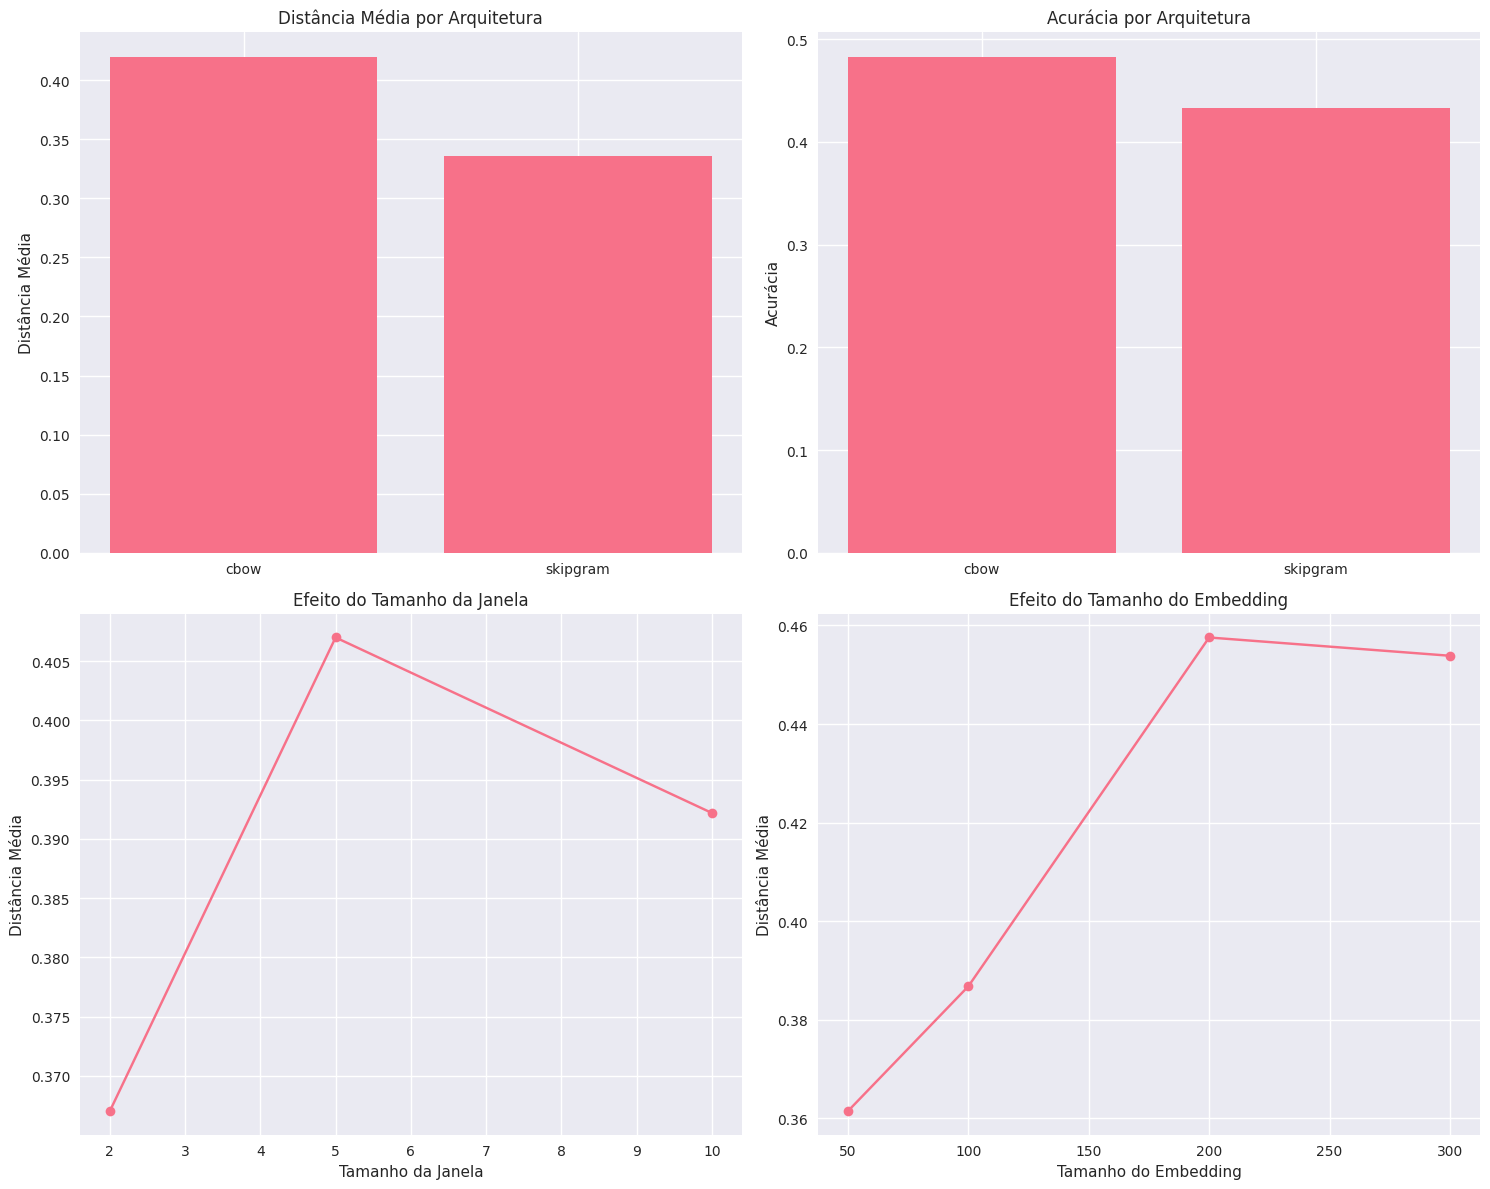

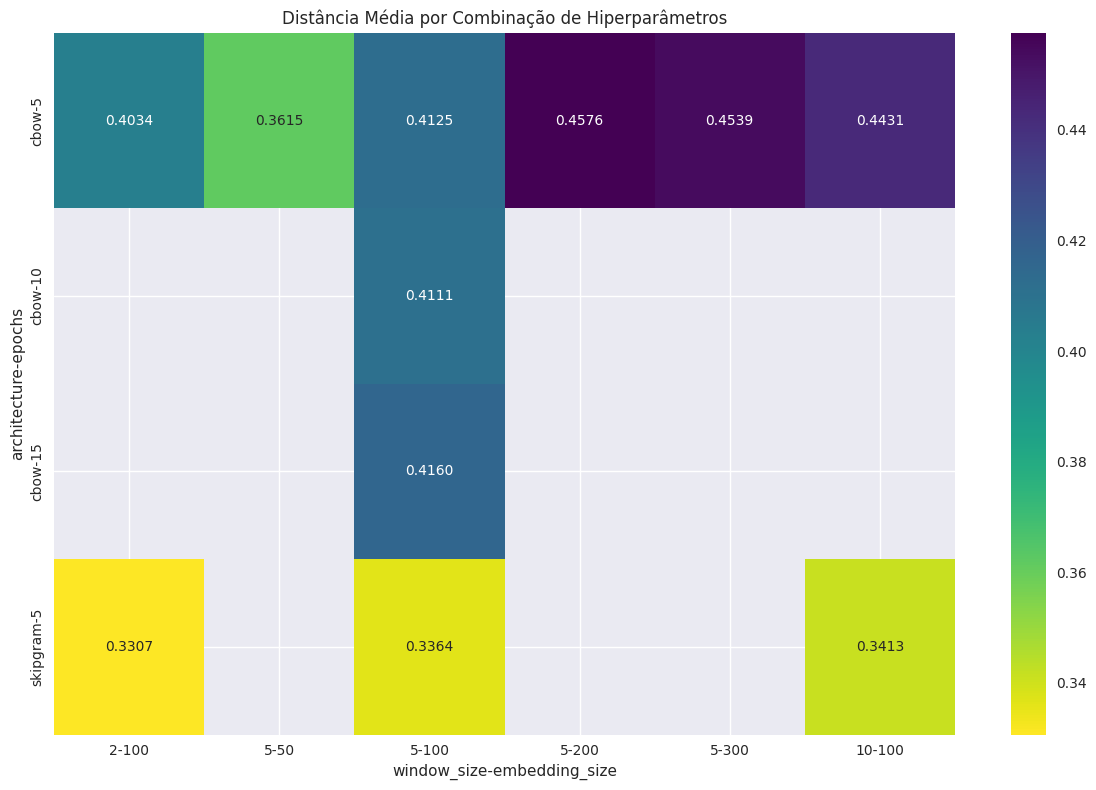

In [9]:
# Melhor modelo
best_model_idx = results_df['avg_distance'].idxmin()
best_model = results_df.loc[best_model_idx]

print("=" * 80)
print("MELHOR MODELO ENCONTRADO:")
print("=" * 80)
print(f"Arquitetura: {best_model['architecture']}")
print(f"Tamanho da janela: {best_model['window_size']}")
print(f"Dimensão do embedding: {best_model['embedding_size']}")
print(f"Número de épocas: {best_model['epochs']}")
print(f"Distância média: {best_model['avg_distance']:.4f}")
print(f"Acurácia: {best_model['accuracy']:.4f}")

# Visualizações
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Comparação CBOW vs Skip-gram
architecture_comparison = results_df.groupby('architecture').agg({
    'avg_distance': 'mean',
    'accuracy': 'mean'
}).reset_index()

axes[0, 0].bar(architecture_comparison['architecture'], architecture_comparison['avg_distance'])
axes[0, 0].set_title('Distância Média por Arquitetura')
axes[0, 0].set_ylabel('Distância Média')

axes[0, 1].bar(architecture_comparison['architecture'], architecture_comparison['accuracy'])
axes[0, 1].set_title('Acurácia por Arquitetura')
axes[0, 1].set_ylabel('Acurácia')

# 2. Efeito do tamanho da janela
window_effect = results_df.groupby('window_size').agg({
    'avg_distance': 'mean',
    'accuracy': 'mean'
}).reset_index()

axes[1, 0].plot(window_effect['window_size'], window_effect['avg_distance'], marker='o')
axes[1, 0].set_title('Efeito do Tamanho da Janela')
axes[1, 0].set_xlabel('Tamanho da Janela')
axes[1, 0].set_ylabel('Distância Média')

# 3. Efeito do tamanho do embedding
embedding_effect = results_df.groupby('embedding_size').agg({
    'avg_distance': 'mean',
    'accuracy': 'mean'
}).reset_index()

axes[1, 1].plot(embedding_effect['embedding_size'], embedding_effect['avg_distance'], marker='o')
axes[1, 1].set_title('Efeito do Tamanho do Embedding')
axes[1, 1].set_xlabel('Tamanho do Embedding')
axes[1, 1].set_ylabel('Distância Média')

plt.tight_layout()
plt.show()

# Heatmap de resultados
pivot_table = results_df.pivot_table(
    values='avg_distance',
    index=['architecture', 'epochs'],
    columns=['window_size', 'embedding_size'],
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='viridis_r')
plt.title('Distância Média por Combinação de Hiperparâmetros')
plt.tight_layout()
plt.show()

Após todos os experimentos, os resultados são consolidados em um DataFrame do pandas para facilitar a análise. Identificamos o melhor modelo com base na menor distância média do cosseno e geramos visualizações comparativas que mostram o desempenho de diferentes arquiteturas, o efeito do tamanho da janela de contexto, e uma visão geral de todos os modelos testados. Os gráficos ajudam a identificar padrões e tendências nos resultados.

In [10]:
# Treina o melhor modelo com mais dados
print("Treinando o melhor modelo...")
best_params = results_df.loc[results_df['avg_distance'].idxmin()]

sg_best = 1 if best_params['architecture'] == 'skipgram' else 0

final_model = Word2Vec(
    sentences=sentences,
    sg=sg_best,
    window=int(best_params['window_size']),
    vector_size=int(best_params['embedding_size']),
    epochs=int(best_params['epochs']),
    min_count=5,
    workers=4
)

# Avaliação final
final_distance, final_accuracy, final_analogies = evaluate_analogies(final_model, max_analogies=1000)

print(f"\nResultados Finais do Melhor Modelo:")
print(f"Distância média: {final_distance:.4f}")
print(f"Acurácia: {final_accuracy:.4f}")

# Exemplos de analogias
print("\nExemplos de Analogias:")
print("=" * 50)

for i, analogy in enumerate(final_analogies[:10]):
    status = "✓" if analogy['correct'] else "✗"
    print(f"{status} {analogy['analogy']}")
    print(f"  Esperado: {analogy['expected']}, Predito: {analogy['predicted']}")
    print(f"  Distância: {analogy['distance']:.4f}\n")

# Exemplos de similaridade
print("\nExemplos de Similaridade:")
print("=" * 50)

test_words = ['king', 'france', 'computer', 'water']
for word in test_words:
    if word in final_model.wv:
        similar = final_model.wv.most_similar(word, topn=5)
        print(f"Palavras similares a '{word}':")
        for sim_word, score in similar:
            print(f"  {sim_word}: {score:.4f}")
        print()

Treinando o melhor modelo...

Resultados Finais do Melhor Modelo:
Distância média: 0.4244
Acurácia: 0.2930

Exemplos de Analogias:
✓ boy:girl :: brother:sister
  Esperado: sister, Predito: sister
  Distância: 0.3468

✓ boy:girl :: brothers:sisters
  Esperado: sisters, Predito: sisters
  Distância: 0.4285

✗ boy:girl :: dad:mom
  Esperado: mom, Predito: lover
  Distância: 0.3971

✓ boy:girl :: father:mother
  Esperado: mother, Predito: mother
  Distância: 0.2591

✓ boy:girl :: grandfather:grandmother
  Esperado: grandmother, Predito: grandmother
  Distância: 0.3013

✗ boy:girl :: grandpa:grandma
  Esperado: grandma, Predito: tina
  Distância: 0.6037

✓ boy:girl :: grandson:granddaughter
  Esperado: granddaughter, Predito: granddaughter
  Distância: 0.2687

✗ boy:girl :: groom:bride
  Esperado: bride, Predito: bed
  Distância: 0.6545

✓ boy:girl :: he:she
  Esperado: she, Predito: she
  Distância: 0.3004

✓ boy:girl :: his:her
  Esperado: her, Predito: her
  Distância: 0.2847


Exemplos 

Geramos quatro visualizações complementares: comparação de arquiteturas (CBOW vs Skip-gram) em termos de distância e acurácia, análise do efeito do tamanho da janela de contexto, e uma visão geral comparando todos os modelos testados. Estas visualizações facilitam a interpretação dos resultados e ajudam a entender como diferentes configurações afetam a qualidade dos embeddings aprendidos.

In [12]:
# Análise estatística
print("ANÁLISE ESTATÍSTICA DOS RESULTADOS:")
print("=" * 50)

print("\nEstatísticas Descritivas:")
print(results_df[['avg_distance', 'accuracy']].describe())

print("\nCorrelações:")
correlation_matrix = results_df[['window_size', 'embedding_size', 'epochs', 'avg_distance', 'accuracy']].corr()
print(correlation_matrix)

print("\nPRINCIPAIS CONCLUSÕES:")
print("=" * 50)

# CORREÇÃO: Verificar se existem modelos de cada arquitetura antes de acessá-los
best_cbow = None
best_skipgram = None

# Encontrar melhor modelo CBOW se existir
cbow_models = results_df[results_df['architecture'] == 'cbow']
if not cbow_models.empty:
    best_cbow_idx = cbow_models['avg_distance'].idxmin()
    best_cbow = cbow_models.loc[best_cbow_idx]

# Encontrar melhor modelo Skip-gram se existir  
skipgram_models = results_df[results_df['architecture'] == 'skipgram']
if not skipgram_models.empty:
    best_skipgram_idx = skipgram_models['avg_distance'].idxmin()
    best_skipgram = skipgram_models.loc[best_skipgram_idx]

# CORREÇÃO: Usar o best_model que já foi definido anteriormente
print(f"1. Melhor arquitetura geral: {best_model['architecture']}")

if best_cbow is not None:
    print(f"2. Melhor CBOW: janela={best_cbow['window_size']}, dim={best_cbow['embedding_size']}, épocas={best_cbow['epochs']}")
else:
    print("2. Nenhum modelo CBOW foi treinado com sucesso")

if best_skipgram is not None:
    print(f"3. Melhor Skip-gram: janela={best_skipgram['window_size']}, dim={best_skipgram['embedding_size']}, épocas={best_skipgram['epochs']}")
else:
    print("3. Nenhum modelo Skip-gram foi treinado com sucesso")

# Efeito dos hiperparâmetros com verificação de dados vazios
print("\n4. Efeito dos hiperparâmetros:")

# CORREÇÃO: Verificar se há dados antes de calcular
arch_effect = results_df.groupby('architecture')['avg_distance'].mean()
if not arch_effect.empty:
    print(f"   - Arquitetura mais eficiente: {arch_effect.idxmin()}")
else:
    print("   - Não há dados suficientes para comparar arquiteturas")

window_effect = results_df.groupby('window_size')['avg_distance'].mean()
if not window_effect.empty:
    print(f"   - Tamanho de janela ideal: {window_effect.idxmin()}")
else:
    print("   - Não há dados suficientes para analisar tamanho de janela")

embedding_effect = results_df.groupby('embedding_size')['avg_distance'].mean()
if not embedding_effect.empty:
    print(f"   - Dimensão de embedding ideal: {embedding_effect.idxmin()}")
else:
    print("   - Não há dados suficientes para analisar dimensão do embedding")

epochs_effect = results_df.groupby('epochs')['avg_distance'].mean()
if not epochs_effect.empty:
    print(f"   - Número de épocas ideal: {epochs_effect.idxmin()}")
else:
    print("   - Não há dados suficientes para analisar número de épocas")

# CORREÇÃO: Adicionar análise de qualidade geral
print(f"\n5. Qualidade geral dos modelos:")
print(f"   - Melhor distância média: {best_model['avg_distance']:.4f}")
print(f"   - Melhor acurácia: {best_model['accuracy']:.4f}")
print(f"   - Total de modelos testados: {len(results_df)}")
print(f"   - Modelos com sucesso: {len(results_df[results_df['avg_distance'] < float('inf')])}")

ANÁLISE ESTATÍSTICA DOS RESULTADOS:

Estatísticas Descritivas:
       avg_distance   accuracy
count     11.000000  11.000000
mean       0.397041   0.469455
std        0.047222   0.067912
min        0.330681   0.370000
25%        0.351398   0.421000
50%        0.411149   0.478000
75%        0.429544   0.515000
max        0.457561   0.574000

Correlações:
                window_size  embedding_size    epochs  avg_distance  accuracy
window_size        1.000000       -0.051504 -0.065395      0.108027 -0.712269
embedding_size    -0.051504        1.000000 -0.154092      0.593959  0.136359
epochs            -0.065395       -0.154092  1.000000      0.170306  0.659512
avg_distance       0.108027        0.593959  0.170306      1.000000  0.258525
accuracy          -0.712269        0.136359  0.659512      0.258525  1.000000

PRINCIPAIS CONCLUSÕES:
1. Melhor arquitetura geral: skipgram
2. Melhor CBOW: janela=5, dim=50, épocas=5
3. Melhor Skip-gram: janela=2, dim=100, épocas=5

4. Efeito dos hiperpa